<a href="https://colab.research.google.com/github/julia-zhmurko/JuliaZhmurko-ML/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D1%96_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B8/%D0%96%D0%BC%D1%83%D1%80%D0%BA%D0%BE_%D0%AE%D0%BB%D1%96%D1%8F_%D0%A4%D0%86%D0%A2_4_10_%22%D0%9B%D0%A03_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%9C%D0%9D_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота 3. Машинне навчання
## Регресія: прогнозування вартості нерухомості

**Мета роботи:** виконати первинний аналіз даних, побудувати кілька моделей регресії, оцінити їхню якість та виконати підбір гіперпараметрів для моделі Random Forest.

### Датасет
Можна використати один із двох способів завантаження даних:

1. Завантажити файл з Google Drive:
https://drive.google.com/file/d/1u_-3X05st6uvrgQB1qNLyE8a7QjTJjvd/view?usp=sharing

2. Завантажити датасет з Kaggle:
https://www.kaggle.com/datasets/prokshitha/home-value-insights

> Посилання та вміст датасету на зовнішніх платформах можуть змінюватися.

**Автор:** студентка групи ФІТ 4-10 Жмурко Юлія Андріївна

**Була присутня на парі (17.09.2026)**

## 1. Імпорт бібліотек
Імпортуйте бібліотеки, необхідні для роботи з даними, візуалізації та числових обчислень.

In [1]:
# Ваш код:
# Імпортуйте pandas, numpy, matplotlib.pyplot, seaborn та інші потрібні бібліотеки.
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Завантаження даних
Оберіть **один** зі способів завантаження датасету.

### Варіант 1. Завантаження файлу з комп’ютера
Завантажте CSV-файл у середовище Colab.

In [2]:
# Ваш код:
# Завантажте файл і збережіть дані у DataFrame `df`.
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print(f"\n Файл '{file_name}' успішно завантажено в середовище Colab!")

Saving house_price_regression_dataset.csv to house_price_regression_dataset.csv

 Файл 'house_price_regression_dataset.csv' успішно завантажено в середовище Colab!


In [3]:
df = pd.read_csv('house_price_regression_dataset.csv')
print(" Дані успішно зчитано у DataFrame 'df'")
print(f" Розмірність датасету: {df.shape[0]} рядків та {df.shape[1]} колонок\n")
df

 Дані успішно зчитано у DataFrame 'df'
 Розмірність датасету: 1000 рядків та 8 колонок



,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


### Варіант 2. Завантаження датасету з Kaggle
Завантажте датасет безпосередньо з Kaggle та прочитайте CSV-файл у DataFrame `df`.

In [4]:
# Ваш код:
import kagglehub
import os

print("Завантаження датасету з Kaggle...")
path = kagglehub.dataset_download("prokshitha/home-value-insights")

print(" Датасет успішно завантажено!")
print("Шлях до файлів датасету:", path)

Завантаження датасету з Kaggle...


100%|██████████| 26.4k/26.4k [00:00<00:00, 40.4MB/s]

Extracting files...
 Датасет успішно завантажено!
Шлях до файлів датасету: /root/.cache/kagglehub/datasets/prokshitha/home-value-insights/versions/1


In [5]:
df = pd.read_csv(os.path.join(path, "house_price_regression_dataset.csv"))

print(" Дані успішно зчитано з Kaggle у DataFrame 'df'!")
print(f" Розмірність датасету: {df.shape[0]} рядків та {df.shape[1]} колонок\n")
print("Перші 5 рядків датасету:")
df.head()

 Дані успішно зчитано з Kaggle у DataFrame 'df'!
 Розмірність датасету: 1000 рядків та 8 колонок

Перші 5 рядків датасету:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 3. Опис ознак датасету

- **Square_Footage** — загальна житлова площа будинку.
- **Num_Bedrooms** — кількість спалень.
- **Num_Bathrooms** — кількість ванних кімнат.
- **Year_Built** — рік побудови будинку.
- **Lot_Size** — розмір земельної ділянки.
- **Garage_Size** — розмір гаража або кількість паркомісць.
- **Neighborhood_Quality** — оцінка якості району.
- **House_Price** — ціна будинку, цільова змінна.

## 4. Первинний аналіз даних

### Завдання 1. Перегляд даних
Виведіть перші рядки датасету та перегляньте його структуру.

In [6]:
# Ваш код:
# Виведіть кілька перших рядків та загальну інформацію про DataFrame.
print("Перші 5 рядків датасету:")
display(df.head())

print("\nЗагальна інформація про датасет:\n")
df.info()

Перші 5 рядків датасету:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06



Загальна інформація про датасет:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


### Завдання 2. Перевірка дублікатів
Визначте кількість дубльованих рядків.

In [7]:
# Ваш код:
# Порахуйте кількість дублікатів.
duplicates_count = df.duplicated().sum()

print(f"Кількість дубльованих рядків у датасеті: {duplicates_count}")

if duplicates_count > 0:
    print("\nДубльовані рядки:")
    display(df[df.duplicated()])
else:
    print("Дублікатів у датасеті не виявлено")

Кількість дубльованих рядків у датасеті: 0
Дублікатів у датасеті не виявлено


### Завдання 3. Перевірка пропущених значень
Визначте кількість пропущених значень у кожному стовпці.

In [8]:
# Ваш код:
# Виведіть кількість пропусків для кожної ознаки.
print("Кількість пропущених значень по кожному стовпцю:")
display(df.isnull().sum())

total_missing = df.isnull().sum().sum()

if total_missing == 0:
    print("\nПропущених значень у датасеті не виявлено!")
else:
    print(f"\nЗагальна кількість пропущених значень у датасеті: {total_missing}")

Кількість пропущених значень по кожному стовпцю:


,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0



Пропущених значень у датасеті не виявлено!


### Завдання 4. Описова статистика
Виведіть основні статистичні характеристики числових ознак.

In [9]:
# Ваш код:
# Отримайте описову статистику датасету.
print("Описова статистика числових ознак датасету:")
df.describe()

Описова статистика числових ознак датасету:


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


## 5. Аналіз окремих ознак

### Завдання 5. Ознака `Neighborhood_Quality`
Виведіть частоти значень ознаки `Neighborhood_Quality`.

In [10]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Neighborhood_Quality`.
quality_counts = df['Neighborhood_Quality'].value_counts().sort_values(ascending = False)

print("Розподіл частот для ознаки Neighborhood_Quality:")
display(quality_counts)

Розподіл частот для ознаки Neighborhood_Quality:


,count
Neighborhood_Quality,
10,123
5,109
2,105
7,102
6,101
4,99
8,97
1,91
9,88


### Завдання 6. Візуалізація `Neighborhood_Quality`
Побудуйте діаграму розподілу значень цієї ознаки.

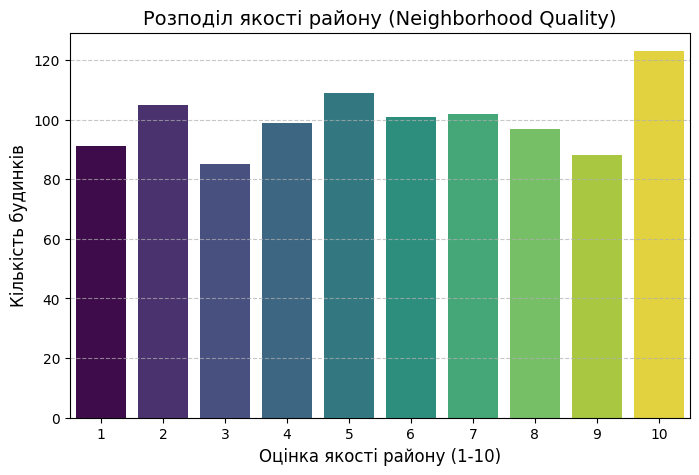

In [11]:
# Ваш код:
# Побудуйте countplot або іншу відповідну діаграму.
plt.figure(figsize = (8, 5))

sns.countplot(data = df, x = 'Neighborhood_Quality', hue = 'Neighborhood_Quality', palette = 'viridis', legend = False)

plt.title('Розподіл якості району (Neighborhood Quality)', fontsize = 14)
plt.xlabel('Оцінка якості району (1-10)', fontsize = 12)
plt.ylabel('Кількість будинків', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

# **Аналіз розподілу якості району:**
* Ознака представлена всіма оцінками від 1 до 10. Кількість будинків у кожній категорії коливається приблизно від 85 до 123 спостережень.

* Найбільша кількість об'єктів має максимальну оцінку якості району 10 (123 будинки) та середній рівень 5 (109 будинків).

### Завдання 7. Ознака `Num_Bathrooms`
Виведіть частоти значень кількості ванних кімнат.

In [12]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Num_Bathrooms`.
bathrooms_counts = df['Num_Bathrooms'].value_counts()

print("Частоти значень кількості ванних кімнат:")
display(bathrooms_counts)

Частоти значень кількості ванних кімнат:


,count
Num_Bathrooms,
1,350
2,327
3,323


### Завдання 8. Візуалізація `Num_Bathrooms`
Побудуйте діаграму розподілу кількості ванних кімнат.

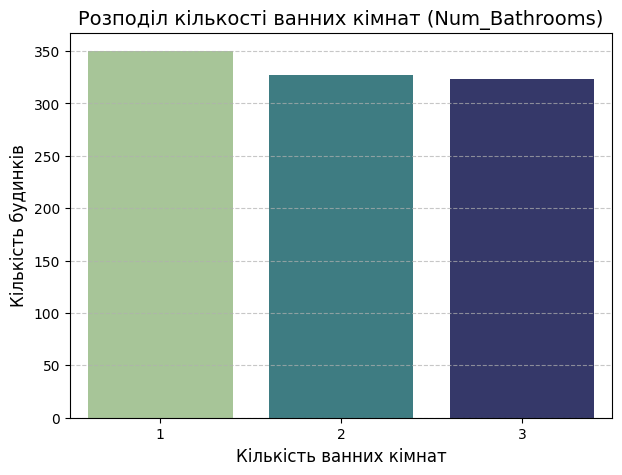

In [13]:
# Ваш код:
# Побудуйте відповідну діаграму.
plt.figure(figsize = (7, 5))

sns.countplot(data = df, x = 'Num_Bathrooms', hue = 'Num_Bathrooms', palette = 'crest', legend = False)

plt.title('Розподіл кількості ванних кімнат (Num_Bathrooms)', fontsize = 14)
plt.xlabel('Кількість ванних кімнат', fontsize = 12)
plt.ylabel('Кількість будинків', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

# **Аналіз розподілу кількості ванних кімнат:**

* Кількість ванних кімнат у будинках розподілена практично порівну між трьома значеннями (1, 2 та 3).

* Найбільше переважають однокімнатні ванні кімнати у близько 350 будинках.

Додатково: визначте частоти значень кількості спальних кімнат.

In [14]:
# Ваш код:
# Порахуйте кількість спостережень для кожного значення `Num_Bedrooms`.
bedroom_counts = df['Num_Bedrooms'].value_counts()

print("Частоти значень кількості спальних кімнат:")
display(bedroom_counts)

Частоти значень кількості спальних кімнат:


,count
Num_Bedrooms,
2,215
5,205
1,201
4,197
3,182


Додатково: побудуйте діаграму розподілу кількості спальних кімнат.

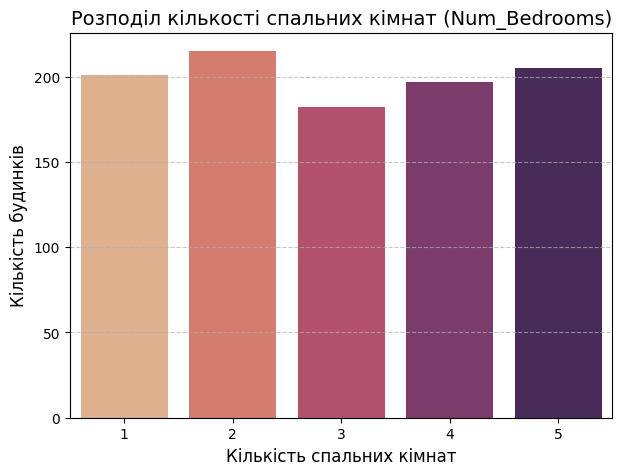

In [15]:
# Ваш код:
# Побудуйте відповідну діаграму.
plt.figure(figsize = (7, 5))

sns.countplot(data = df, x = 'Num_Bedrooms', hue = 'Num_Bedrooms', palette = 'flare', legend = False)

plt.title('Розподіл кількості спальних кімнат (Num_Bedrooms)', fontsize = 14)
plt.xlabel('Кількість спальних кімнат', fontsize = 12)
plt.ylabel('Кількість будинків', fontsize = 12)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.show()

# **Аналіз розподілу кількості спальних кімнат:**

* Кількість спалень у будинках вар'юється від 1 до 5, причому об'єкти розподілені практично порівну між усіма категоріями (приблизно по 180–215 у кожному будинку).

* Найчастіше зустрічаються будинки з 2 спальнями та 5 спальнями, а найменше — з 3 спальнями.

### Додаткове завдання
За потреби побудуйте попарні графіки числових ознак і коротко проаналізуйте можливі залежності.

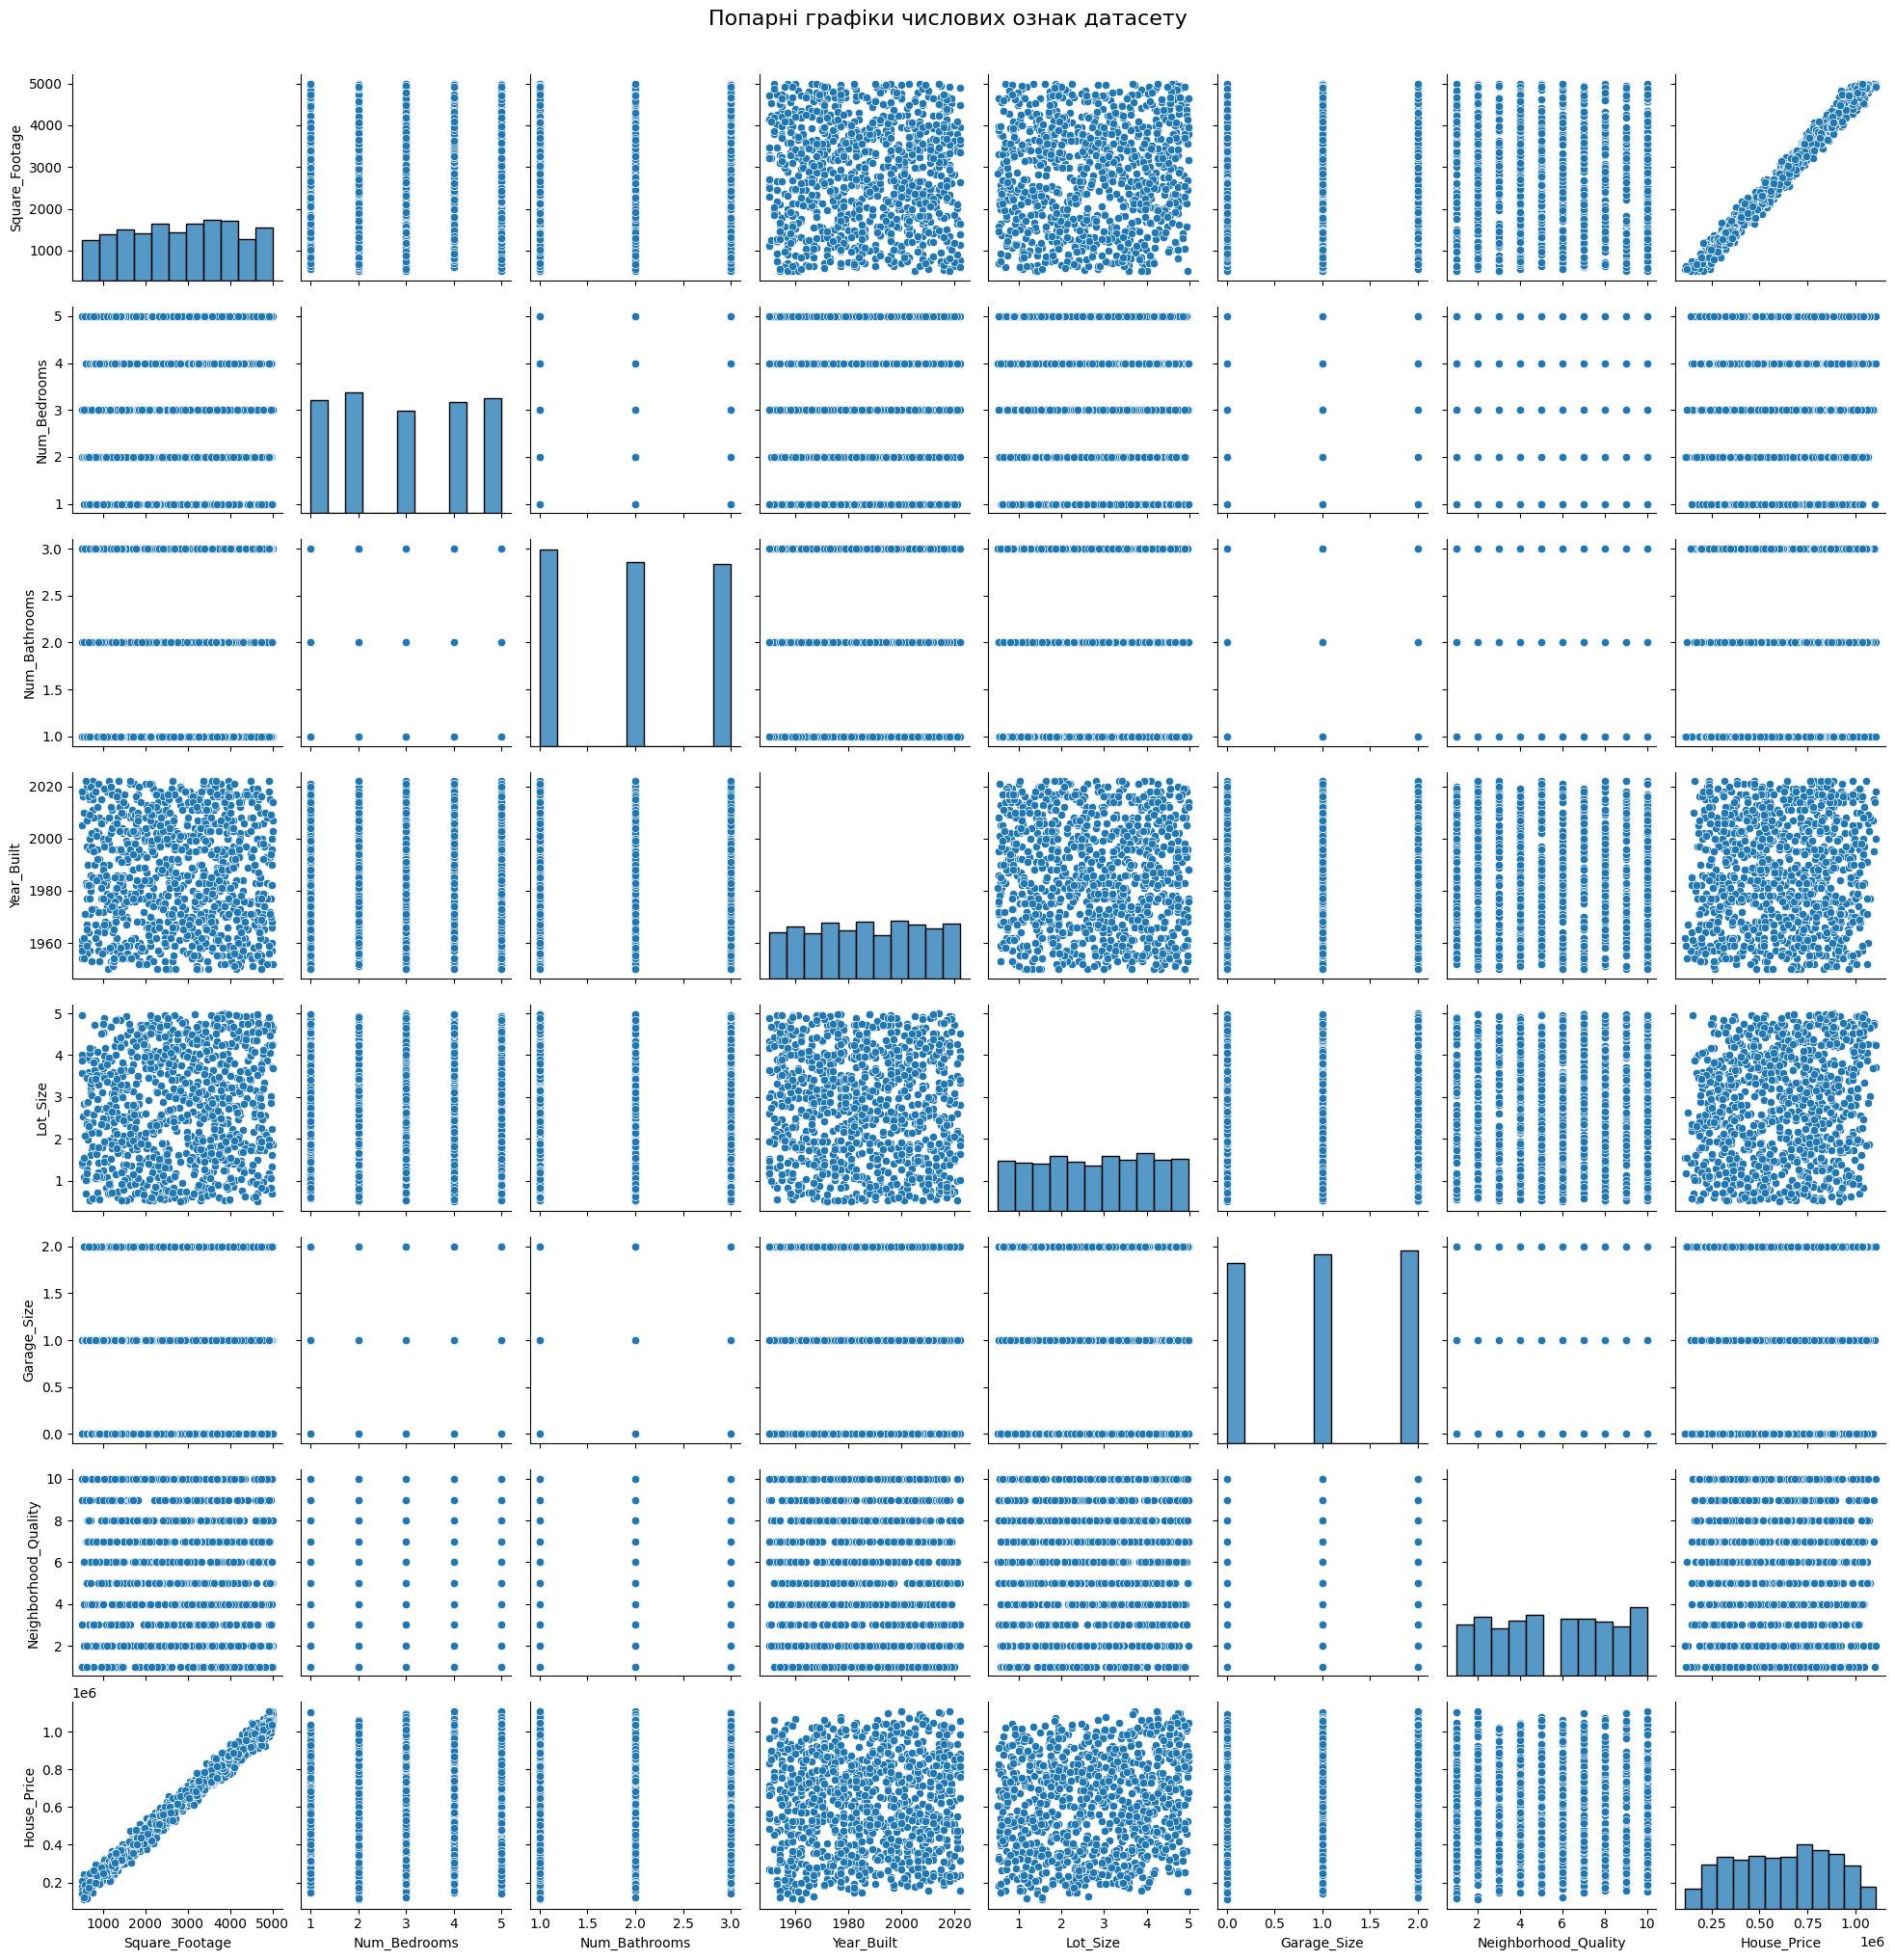

In [16]:
# Ваш код:
# Побудуйте pairplot або іншу попарну візуалізацію.
sns.pairplot(df)
plt.suptitle('Попарні графіки числових ознак датасету', y = 1.02, fontsize = 16)
plt.show()

# **Аналіз взаємозв'язків між ознаками:**
* **Сильна лінійна залежність (Square_Footage та House_Price):** На графіку розсіювання чітко видно виражену пряму лінійну залежність між площею будинку (`Square_Footage`) та його ціною (`House_Price`). З зі збільшенням площі вартість нерухомості зростає практично пропорційно.

* **Слабкі помірні зв'язки (Lot_Size):** Розмір земельної ділянки (`Lot_Size`) має незначний позитивний тренд стосовно вартості, однак точки розсіяні досить хаотично, що свідчить про другорядний вплив цієї ознаки.

* **Дискретні та категоріальні ознаки:** Ознаки `Num_Bedrooms`, `Num_Bathrooms`, `Garage_Size` та `Neighborhood_Quality` мають дискретний характер (приймають цілі значення). На графіках розсіювання точки утворюють вертикальні лінії, що свідчить про відсутність прямої лінійної залежності між ними та ціною у даному датасеті.

* **Розподіли змінних (гістограми по діагоналі):** Більшість неперервних та дискретних змінних мають відносно рівномірний розподіл у своїх діапазонах без яскраво виражених аномальних викидів.

## 6. Кореляційний аналіз

### Завдання 9. Матриця кореляції
Побудуйте кореляційну матрицю для числових ознак та відобразіть її у вигляді теплової карти.

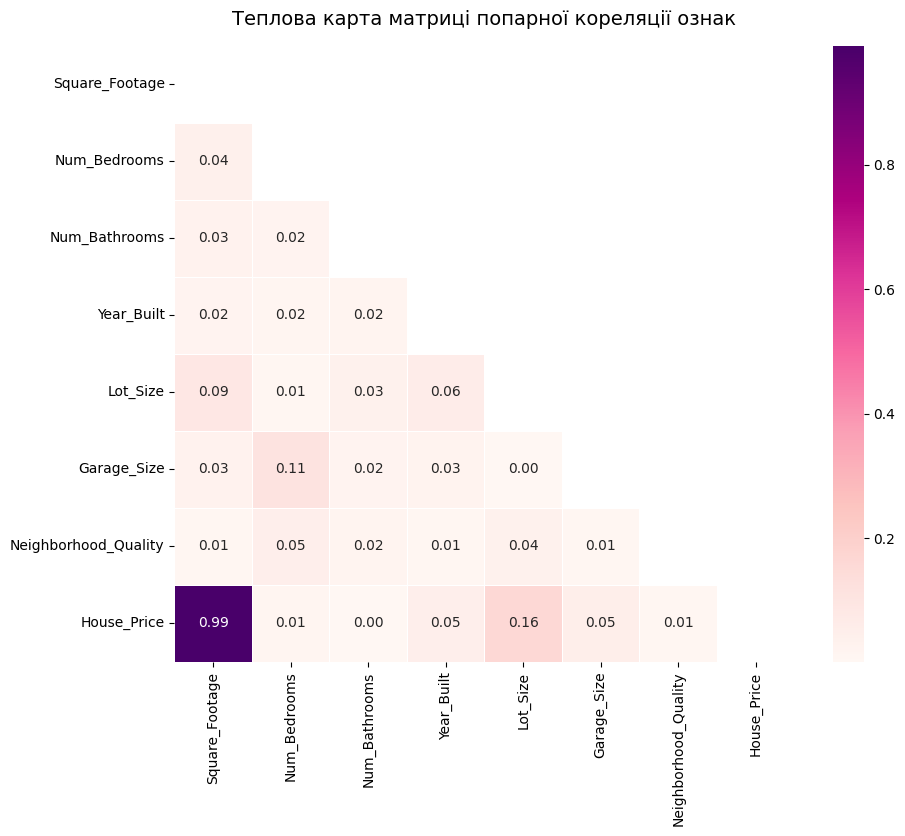

In [17]:
# Ваш код:
# Обчисліть кореляційну матрицю та побудуйте heatmap.
corr_matrix_abs = df.corr().abs()

plt.figure(figsize = (10, 8))

sns.heatmap(
    corr_matrix_abs,
    mask = np.triu(np.ones_like(corr_matrix_abs, dtype = bool)),
    annot = True,
    fmt = '.2f',
    cmap = 'RdPu',
    linewidths = 0.5
)

plt.title('Теплова карта матриці попарної кореляції ознак', fontsize = 14, pad = 15)
plt.show()

# **Аналіз матриці кореляцій:**

* Спостерігається майже ідеальний зв'язок між площею будинку та його вартістю (`House_Price`), де коефіцієнт кореляції за модулем становить 0.99. Це означає, що саме площа є головним фактором, який визначає ціну нерухомості в даному датасеті.

* Розмір ділянки має слабкий зв'язок з ціною (0.16). Дана ознака додає незначну інформацію, але її вплив значно менший за площу самого будинку.

* Усі інші ознаки (`Num_Bedrooms`, `Num_Bathrooms`, `Year_Built`, `Garage_Size`, `Neighborhood_Quality`) мають дуже низьку кореляцію як між собою (від 0.00 до 0.11), так і з ціною `House_Price` (від 0.00 до 0.05).

### Завдання 10. Кореляція з цільовою змінною
Виведіть кореляцію кожної ознаки з `House_Price`, відсортувавши значення за спаданням.

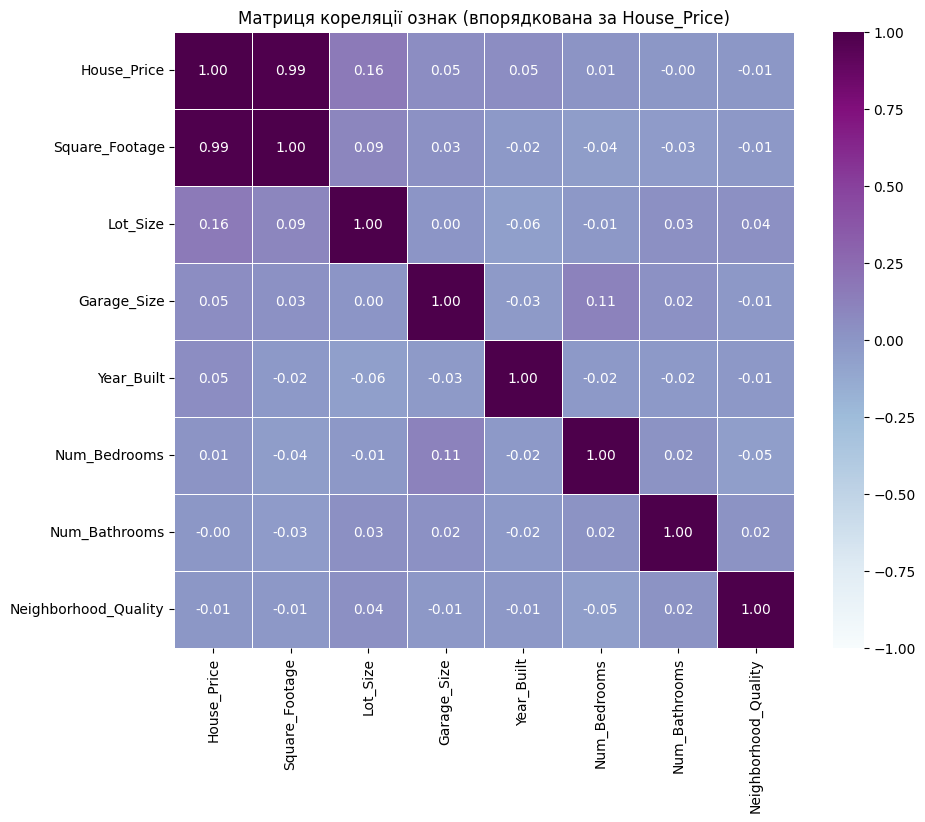

In [18]:
# Ваш код:
# Виведіть кореляції ознак із `House_Price`.

# Сортуємо колонки за спаданням кореляції з цільовою змінною
sorted_cols = df.corr()['House_Price'].sort_values(ascending = False).index
sorted_corr = df[sorted_cols].corr()

plt.figure(figsize = (10, 8))
sns.heatmap(
    sorted_corr,
    annot = True,
    fmt = '.2f',
    cmap = 'BuPu',
    vmin = -1,
    vmax = 1,
    linewidths = 0.5)

plt.title('Матриця кореляції ознак (впорядкована за House_Price)')
plt.show()


# **Аналіз матриці кореляцій впорядкованою за ціною будинку:**

* Між ціною нерухомості (`House_Price`) та площею будинку (`Square_Footage`) спостерігається майжe ідеальна позитивна кореляція ($r = 0.99$), що свідчить про те, що саме площа є головним критерієм ціни у даному датасеті.  

* Розмір земельної ділянки (`Lot_Size`) має незначний позитивний зв'язок із ціною ($r = 0.16$). Інші ознаки (`Garage_Size` $0.05$, `Year_Built` $0.05$, `Num_Bedrooms` $0.01$) майже не мають лінійного зв'язку з цільовою змінною.

* Кількість ванних кімнат (`Num_Bathrooms`) та якість району (`Neighborhood_Quality`) мають практично нульову або незначну негативну кореляцію з ціною ($-0.00$ та $-0.01$ відповідно).

In [19]:
target_corr = df.corr()['House_Price'].sort_values(ascending = False)

target_corr_df = target_corr.to_frame(name = 'Correlation_with_House_Price')

print("Кореляція ознак із цільовою змінною (House_Price):\n")
display(target_corr_df)

Кореляція ознак із цільовою змінною (House_Price):



,Correlation_with_House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


## 7. Побудова моделей регресії

### Завдання 11. Імпорт інструментів Scikit-learn
Імпортуйте засоби для:
- поділу вибірки;
- масштабування ознак;
- побудови Linear Regression, Ridge, Lasso, Random Forest та Gradient Boosting;
- створення Pipeline;
- обчислення R², MAE та MSE.

In [20]:
# Ваш код:
# Імпортуйте необхідні класи та функції зі scikit-learn.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

### Завдання 12. Формування `X` і `y`
Відокремте ознаки від цільової змінної `House_Price`.

In [21]:
# Ваш код:
# Створіть `X` та `y`.
X = df.drop(columns = ['House_Price'])
y = df['House_Price']

print(f"Розмірність матриці ознак X: {X.shape}")
print(f"Розмірність вектора цільової змінної y: {y.shape}")

Розмірність матриці ознак X: (1000, 7)
Розмірність вектора цільової змінної y: (1000,)


### Завдання 13. Поділ даних
Поділіть дані на навчальну і тестову вибірки у співвідношенні 80/20. Для відтворюваності використайте `random_state=42`.

In [22]:
# Ваш код:
# Створіть `X_train`, `X_test`, `y_train`, `y_test`.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

print(f"Розмірність X_train (навчальні ознаки): {X_train.shape}")
print(f"Розмірність X_test (тестові ознаки): {X_test.shape}")
print(f"Розмірність y_train (навчальні цільові значення): {y_train.shape}")
print(f"Розмірність y_test (тестові цільові значення): {y_test.shape}")

Розмірність X_train (навчальні ознаки): (800, 7)
Розмірність X_test (тестові ознаки): (200, 7)
Розмірність y_train (навчальні цільові значення): (800,)
Розмірність y_test (тестові цільові значення): (200,)


### Завдання 14. Створення моделей
Створіть п’ять моделей:
1. Linear Regression;
2. Ridge;
3. Lasso;
4. Random Forest Regressor;
5. Gradient Boosting Regressor.

Для лінійних моделей використайте `Pipeline` зі `StandardScaler`. Для деревоподібних моделей масштабування не потрібне.

In [23]:
# Ваш код:
# Створіть словник або іншу структуру з п’ятьма моделями.
models = {
    "LinearRegression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),

    "Ridge": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha = 1.0))
    ]),

    "Lasso": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha = 0.1, max_iter = 10000))
    ]),

    "Random Forest": RandomForestRegressor(
        random_state = 42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state = 42
        )
}

print("Словник моделей успішно створено:")
for name in models.keys():
    print(f"- {name}")

Словник моделей успішно створено:
- LinearRegression
- Ridge
- Lasso
- Random Forest
- Gradient Boosting


### Завдання 15. Навчання та оцінювання моделей
Для кожної моделі:
- виконайте навчання на тренувальній вибірці;
- отримайте прогноз для тестової вибірки;
- обчисліть `R²`, `MAE`, `MSE`;
- збережіть результати для подальшого порівняння.

In [24]:
# Ваш код:
# Навчіть усі моделі, отримайте прогнози та метрики на тестовій вибірці.
results = []

# Цикл для навчання та оцінювання кожної моделі
for name, model in models.items():
    # Навчання моделі
    model.fit(X_train, y_train)

    # Прогноз для тестової вибірки
    y_pred = model.predict(X_test)

    # Обчислення метрик
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    results.append({
        'model': name,
        'R²': r2,
        'MAE': mae,
        'MSE': mse,
        'MAPE': mape
    })

results_df = pd.DataFrame(results)

print("Результати оцінювання моделей:\n")
display(results_df)

Результати оцінювання моделей:



,model,R²,MAE,MSE,MAPE
0,LinearRegression,0.998426,8174.583600,1.014348e+08,0.016639
1,Ridge,0.998410,8241.586911,1.024810e+08,0.016798
2,Lasso,0.998426,8174.606740,1.014351e+08,0.016639
3,Random Forest,0.993886,16114.289644,3.941317e+08,0.032427
4,Gradient Boosting,0.996510,12305.217615,2.249656e+08,0.024807


### Завдання 16. Графічне порівняння прогнозів
Для кожної моделі побудуйте графік **фактичні значення vs прогнозовані значення**. Додайте лінію ідеального прогнозу.

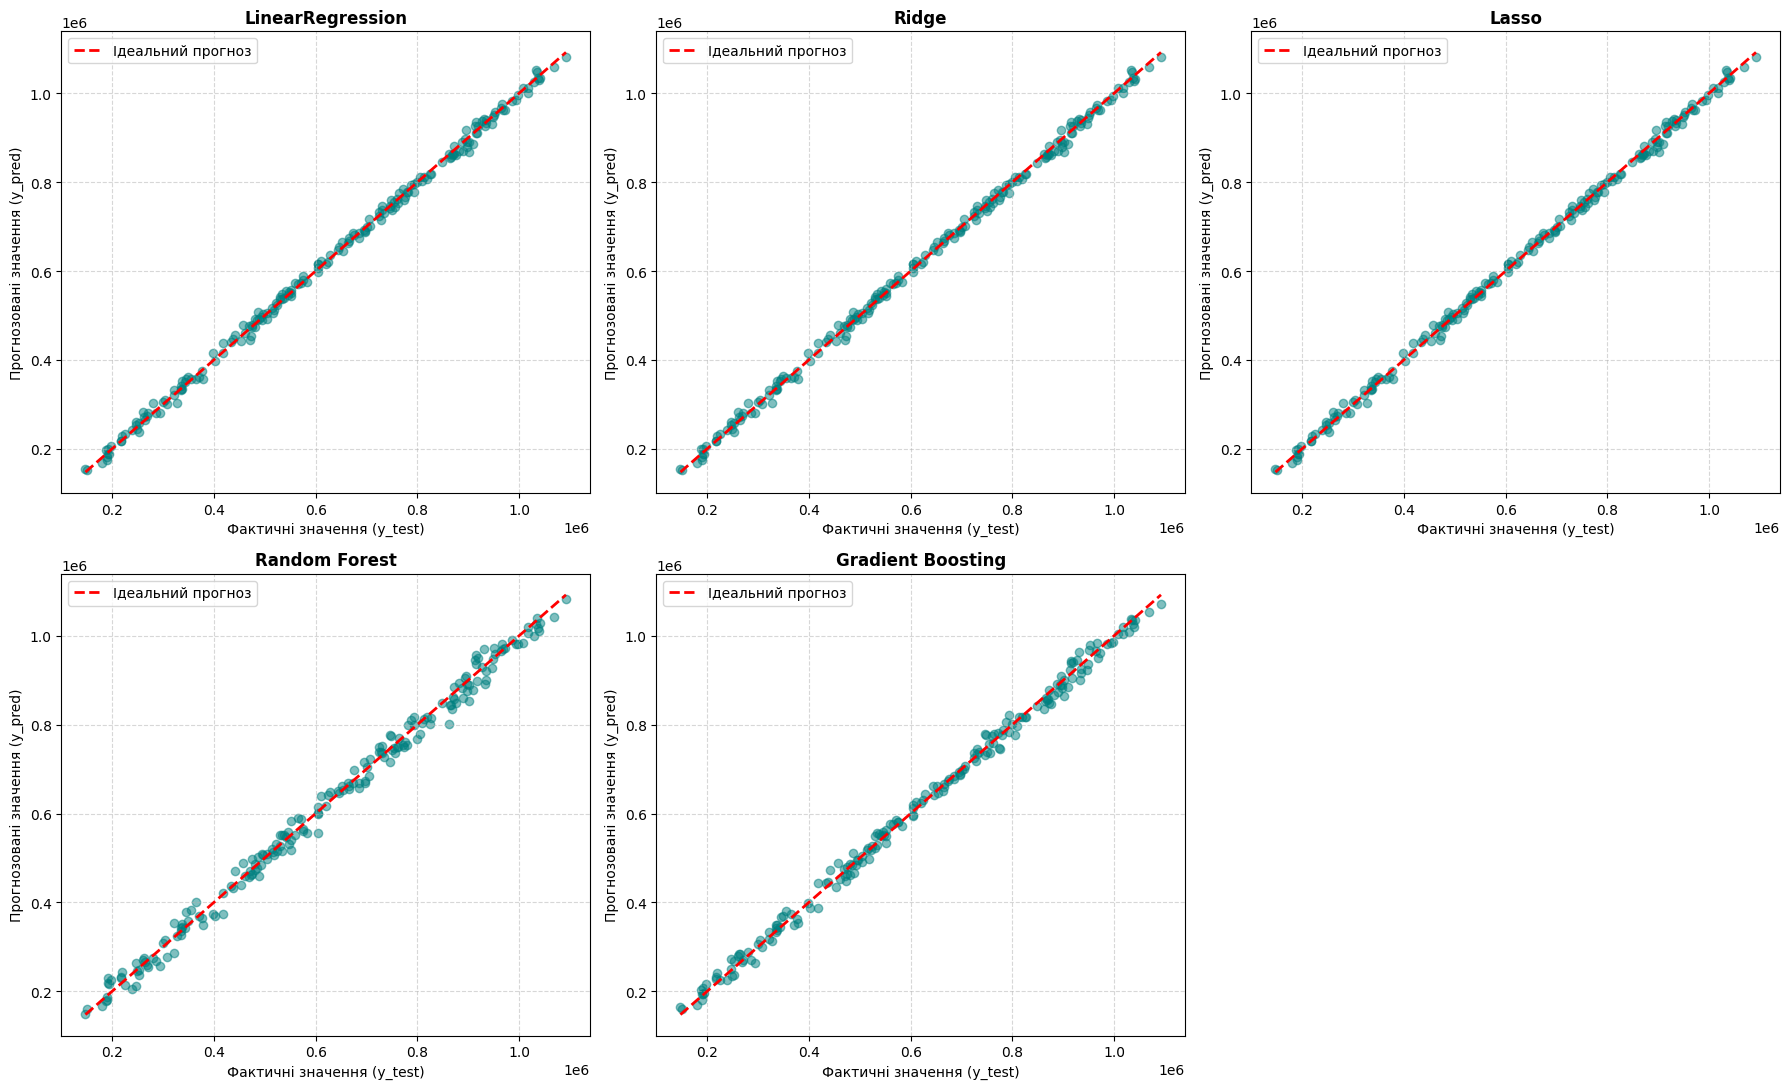

In [25]:
# Ваш код:
# Побудуйте окремий графік для кожної моделі.
fig, axes = plt.subplots(2, 3, figsize = (18, 11))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    # Точкова діаграма фактичних проти прогнозованих значень
    axes[idx].scatter(y_test, y_pred, alpha = 0.5, color = 'teal')

    # Лінія ідеального прогнозу (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2, label = 'Ідеальний прогноз')

    axes[idx].set_title(f'{name}', fontsize = 12, fontweight = 'bold')
    axes[idx].set_xlabel('Фактичні значення (y_test)', fontsize = 10)
    axes[idx].set_ylabel('Прогнозовані значення (y_pred)', fontsize = 10)
    axes[idx].grid(True, linestyle = '--', alpha = 0.5)
    axes[idx].legend()

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# **Аналіз графіків фактичних vs прогнозованих значень моделей:**

* Точки прогнозу для всіх моделей щільно групуються уздовж червоної пунктирної лінії ідеального прогнозу ($y = x$), що свідчить про високу якість передбачення вартості нерухомості на тестовій вибірці.

* `LinearRegression`, `Ridge` та `Lasso` демонструють найменший розкид точок відносно діагоналі. Це пояснюється тим, що цільова змінна (`House_Price`) має сильную лінійну залежність від ключової ознаки (`Square_Footage`).

* Графіки `Random Forest` та `Gradient Boosting` мають трохи ширшу хмару розсіювання точок уздовж лінії.

## 8. Підбір гіперпараметрів Random Forest

### Завдання 17. GridSearchCV
Виконайте підбір оптимальних параметрів для `RandomForestRegressor` за допомогою `GridSearchCV`.

Дослідіть щонайменше такі параметри:
- `n_estimators`;
- `max_features`;
- `max_depth`;
- `min_samples_split`.

Використайте крос-валідацію та метрику `R²`.

In [26]:
# Ваш код:
# Створіть сітку параметрів, GridSearchCV і знайдіть найкращі параметри.
from sklearn.model_selection import GridSearchCV

# Визначення сітки гіперпараметрів
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Ініціалізація базової моделі
rf = RandomForestRegressor(random_state = 42)

grid_search = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2',
    n_jobs = -1,
)

# Навчання та пошук оптимальних параметрів
print("Розпочато підбір гіперпараметрів за допомогою GridSearchCV...")
grid_search.fit(X_train, y_train)

print("\nНайкращі параметри (Best Parameters):")
print(grid_search.best_params_)

print(f"\nНайкраща оцінка R² на крос-валідації: {grid_search.best_score_:.4f}")

Розпочато підбір гіперпараметрів за допомогою GridSearchCV...

Найкращі параметри (Best Parameters):
{'max_depth': None, 'max_features': None, 'min_samples_split': 2, 'n_estimators': 200}

Найкраща оцінка R² на крос-валідації: 0.9920


### Завдання 18. Оптимізована модель Random Forest
Створіть нову модель з найкращими параметрами, навчіть її та обчисліть `R²`, `MAE`, `MSE` на тестовій вибірці.

In [27]:
# Ваш код:
# Навчіть оптимізований Random Forest та обчисліть метрики.
best_rf = RandomForestRegressor(
    **grid_search.best_params_,
    random_state = 42)

best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test)

r2_opt = r2_score(y_test, y_pred_best)
mae_opt = mean_absolute_error(y_test, y_pred_best)
mse_opt = mean_squared_error(y_test, y_pred_best)
mape_opt = mean_absolute_percentage_error(y_test, y_pred_best)

print("Метрики якості для оптимізованої моделі Random Forest:\n")
print(f"R²: {r2_opt}")
print(f"MAE: {mae_opt}")
print(f"MSE: {mse_opt}")
print(f"MAPE: {mape_opt}")

Метрики якості для оптимізованої моделі Random Forest:

R²: 0.9939926162295505
MAE: 16035.16807954079
MSE: 387229091.9214415
MAPE: 0.03230560862939432


### Завдання 19. Порівняння Random Forest до і після оптимізації
Порівняйте значення `R²`, `MAE` і `MSE` для базової та оптимізованої моделей.

In [28]:
# Ваш код:
# Виведіть результати двох моделей у зручному для порівняння вигляді.
rf_base_metrics = results_df[results_df['model'] == 'Random Forest'].iloc[0]

comparison_df = pd.DataFrame({
    'Метрика': ['R²', 'MAE', 'MSE', 'MAPE'],
    'До оптимізації (Базова)': [
        rf_base_metrics['R²'],
        rf_base_metrics['MAE'],
        rf_base_metrics['MSE'],
        rf_base_metrics['MAPE']
    ],
    'Після оптимізації (GridSearchCV)': [
        r2_opt,
        mae_opt,
        mse_opt,
        mape_opt
    ]
})

print("Порівняння результатів Random Forest до та після оптимізації:\n")
display(comparison_df)

Порівняння результатів Random Forest до та після оптимізації:



,Метрика,До оптимізації (Базова),Після оптимізації (GridSearchCV)
0,R²,9.938855e-01,9.939926e-01
1,MAE,1.611429e+04,1.603517e+04
2,MSE,3.941317e+08,3.872291e+08
3,MAPE,3.242652e-02,3.230561e-02


### Завдання 20. Аналіз оптимізації
Зробіть короткий висновок:
- чи покращилася якість моделі після підбору параметрів;
- які метрики змінилися;
- чи доцільно використовувати оптимізовану модель.

**Ваш висновок:**

# **Висновок до аналізу оптимізації моделі Random Forest:**

Після підбору гіперпараметрів за допомогою GridSearchCV якість моделі Random Forest незначно, але помітно зросла. Модель стала краще узагальнювати дані на тестовій вибірці.

`R²` (Коефіцієнт детермінації): збільшився з $0.993886$ до $0.993993$, що свідчить про високу точність пояснення дисперсії цільової змінної.

`MAE` (Середня абсолютна помилка) зменшилася з $16114.29$ до $16035.17$.

`MSE` (Середньоквадратична помилка): зменшилася з $394.13 \text{ млн}$ до $387.23 \text{ млн}$, що вказує на зменшення кількості великих помилок/викидів у прогнозах.

`MAPE` (Середня відносна помилка): зменшилася з $3.24\%$ до $3.23\%$, підтверджуючи високу точність моделей.

Використовувати оптимізовану модель доцільно. Попри те, що базова модель вже показувала високі результати (`R²`>0.99), настроювання гіперпараметрів дозволило додатково зменшити середню помилку прогнозування без виникнення ефекту перенавчання.

## 9. Аналіз прогнозів лінійної регресії

### Завдання 21. Таблиця прогнозів
Для моделі Linear Regression створіть таблицю з трьома стовпцями:
- фактична ціна;
- прогнозована ціна;
- похибка у відсотках.

Виведіть 10 випадкових рядків.

In [34]:
# Ваш код:
# Сформуйте DataFrame з фактичними та прогнозованими значеннями і розрахуйте похибку у %.
y_pred_lr = model.predict(X_test)

predictions_df = pd.DataFrame({
    'Фактична ціна': y_test,
    'Прогнозована ціна': y_pred_lr,
    'Похибка (%)': np.abs((y_test - y_pred_lr) / y_test) * 100
})

predictions_df = predictions_df.round(2)

display(predictions_df.sample(10, random_state = 42))

,Фактична ціна,Прогнозована ціна,Похибка (%)
436,1068538.11,1052716.15,1.48
899,194353.74,196288.37,1.00
346,270230.64,270043.73,0.07
60,986006.86,980516.56,0.56
867,953339.73,978666.80,2.66
432,914555.75,943123.39,3.12
543,746167.73,730867.62,2.05
361,646766.29,642496.38,0.66
486,523323.07,525892.96,0.49
277,1008539.16,1004063.81,0.44


## 10. Висновки
Сформулюйте загальний висновок за результатами лабораторної роботи. Вкажіть:

1. Які моделі було побудовано.
2. Яка модель показала найкращі значення метрик.
3. Як вплинув підбір гіперпараметрів Random Forest.
4. Наскільки точними є прогнози на тестовій вибірці.
5. Які фактори можуть впливати на якість прогнозування ціни нерухомості.

**Загальний висновок:**

# **Підсумковий висновок до лабораторної роботи:**

1. У ході виконання роботи було побудовано, навчено та оцінено 5 моделей регресії (`LinearRegression`, `Ridge`, `Lasso`, `RandomForestRegressor`, `GradientBoostingRegressor`) для прогнозування вартості нерухомості (`House_Price`).

2. Лінійні моделі (`LinearRegression`, `Lasso`, `Ridge`) продемонстрували найкращі результати. Моделі `LinearRegression` та `Lasso` досягли найвищого коефіцієнта детермінації ($R^2 \approx 0.9984$) та найменших помилок ($MAE \approx 8174.58$, $MAPE \approx 1.66\%$). Це свідчить про наявність вираженої лінійної залежності між цільовою змінною та основними ознаками (зокрема, площею нерухомості `Square_Footage`).

3. За допомогою підбору параметрів для `RandomForestRegressor` (n_estimators: 200, max_features: None, max_depth: None, min_samples_split: 2) вдалося покращити точність моделі:

* $R^2$ зростав з 0.993886 до 0.993993.
* $MAE$ зменшилася з 16114.29 до 16035.17.
* $MSE$ зменшився з $3.94 \times 10^8$ до $3.87 \times 10^8$.

4. Прогнози є виключно точними, так як лінійні моделі пояснюють 99.84% варіації ціни ($R^2 \approx 0.9984$) із середньою відносною помилкою лише 1.66% ($MAPE$). Ансамблеві моделі (`Random Forest`, `Gradient Boosting`) також показали високу точність ($R^2 > 0.993$, $MAPE \approx 3.24\%$). На графіках «Фактичні значення vs Прогнозовані значення» точки прогнозу щільно групуються вздовж лінії ідеального прогнозу ($y = x$).

5. На якість прогнозування ціни нерухомості суттєво впливає наявність сильної лінійної залежності між цільовою змінною та основними ознаками, зокрема площею нерухомості (`Square_Footage`). Крім того, важливу роль відіграє належна попередня обробка даних, що включає застосування масштабування ознак (`StandardScaler`).

Для даного набору даних найбільш ефективною виявилася модель `Linear Regression`, оскільки вона забезпечила мінімальну абсолютну помилку прогнозу та найвищий коефіцієнт детермінації при меншій обчислюваній складності.